# White Matter FA as a Predictor of DBS Outcomes in Parkinson's Disease
**Morrison Lab, UCSF** | Analysis notebook accompanying the manuscript


**Data:** `DBS_FA_cohort_data.xlsx` - `data` sheet holds the cohort; `data_dictionary` sheet defines every column. Place in the same directory as this notebook.

---
## 1. Setup & Data Loading <a id='1-setup'></a>

In [1]:
import os

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from matplotlib.patches import Patch
from matplotlib.lines import Line2D
import matplotlib.ticker as mticker
from scipy import stats
from sklearn.linear_model import Lasso, LassoCV
from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline

os.makedirs('figures', exist_ok=True)

# global plot style 
FONT = 'Arial'
plt.rcParams.update({
    'font.family': 'sans-serif',
    'font.sans-serif': [FONT, 'DejaVu Sans'],
    'axes.spines.top': False,
    'axes.spines.right': False,
    'axes.linewidth': 0.8,
    'xtick.major.width': 0.8,
    'ytick.major.width': 0.8,
    'xtick.labelsize': 10,
    'ytick.labelsize': 10,
    'axes.labelsize': 11,
    'axes.titlesize': 12,
    'legend.fontsize': 9,
    'figure.dpi': 150,
})

# palette (color-blind friendly)

C = {
    'M1': '#BDBDBD',        # neutral gray  — clinical only
    'M2': '#6BAED6',        # muted blue    — + whole-brain FA
    'M3': '#238B45',        # dark green    — + tract-specific FA
    'stable': '#238B45',
    'unstable': '#D9D9D9',
    'tp_03': '#FC8D59',     # 0-3 months
    'tp_36': '#91BFDB',     # 3-6 months (priority)
    'tp_612': '#4DAC26',    # 6-12 months
    'stn': '#4292C6',
    'gpi': '#E6550D',
}

SAVE_DPI = 300
SAVE_FMT = 'tiff'

def savefig(name):
    plt.savefig(f'figures/{name}.{SAVE_FMT}', dpi=SAVE_DPI,
                bbox_inches='tight', format=SAVE_FMT)

print('setup done')

setup done


In [2]:
# OLS helpers 

def ols_fit(X, y):
    """OLS via lstsq"""
    X = np.asarray(X, dtype=float)
    y = np.asarray(y, dtype=float)
    n, p = X.shape
    Xc = np.column_stack([np.ones(n), X])   
    k  = Xc.shape[1]                         

    coef, _, _, _ = np.linalg.lstsq(Xc, y, rcond=None)
    yhat  = Xc @ coef
    resid = y - yhat

    rss = float(resid @ resid)
    tss = float(((y - y.mean()) ** 2).sum())
    r2      = 1 - rss / tss
    r2_adj  = 1 - (1 - r2) * (n - 1) / (n - k)

    # log-likelihood under normality to AIC
    sigma2  = rss / n
    ll      = -n / 2 * np.log(2 * np.pi * sigma2) - rss / (2 * sigma2)
    aic     = 2 * k - 2 * ll

    # overall F-test (vs. intercept-only)
    df_model = k - 1
    df_resid  = n - k
    f_stat    = (r2 / df_model) / ((1 - r2) / df_resid) if df_resid > 0 else np.nan
    f_pval    = 1 - stats.f.cdf(f_stat, df_model, df_resid)

    # coefficient SE, t-stats, p-values
    mse  = rss / df_resid
    cov  = mse * np.linalg.pinv(Xc.T @ Xc)
    se   = np.sqrt(np.diag(cov))
    t    = coef / se
    pval = 2 * stats.t.sf(np.abs(t), df=df_resid)

    rmse = np.sqrt(rss / n)
    mae  = np.mean(np.abs(resid))

    return dict(
        coef=coef, se=se, t=t, pval=pval,
        yhat=yhat, resid=resid, n=n, k=k,
        rss=rss, tss=tss, r2=r2, r2_adj=r2_adj,
        aic=aic, f_stat=f_stat, f_pval=f_pval,
        rmse=rmse, mae=mae,
    )


def nested_f_test(res_reduced, res_full):
    """nested F-test"""
    rss_r = res_reduced['rss'];  k_r = res_reduced['k']
    rss_f = res_full['rss'];     k_f = res_full['k']
    n     = res_full['n']
    df1   = k_f - k_r
    df2   = n - k_f
    if df1 <= 0 or df2 <= 0:
        return np.nan, df1, df2, np.nan
    F = ((rss_r - rss_f) / df1) / (rss_f / df2)
    p = 1 - stats.f.cdf(F, df1, df2)
    return float(F), int(df1), int(df2), float(p)


def prepare_Xy(df, outcome, predictors):
    """drop rows missing outcome/predictors, median-impute, z-score; returns (X_std, y, mask)."""
    d = df.copy()
    d[predictors] = d[predictors].apply(pd.to_numeric, errors='coerce')
    mask = d[outcome].notna() & d[predictors].notna().all(axis=1)
    d = d.loc[mask].copy()

    X = d[predictors].values.astype(float)
    # Median-impute any remaining NaNs (e.g. tract FA)
    for j in range(X.shape[1]):
        col = X[:, j]
        X[col != col, j] = np.nanmedian(col)

    # Standardise
    mu  = X.mean(0)
    sd  = X.std(0, ddof=1)
    sd[sd == 0] = 1
    X_std = (X - mu) / sd

    y = d[outcome].values.astype(float)
    return X_std, y, mask


def fit_model(df, outcome, predictors):
    """prepare data then fit OLS"""
    X, y, mask = prepare_Xy(df, outcome, predictors)
    res = ols_fit(X, y)
    res['predictors'] = predictors
    res['mask'] = mask
    return res


print('OLS helpers defined')

OLS helpers defined


In [3]:
# load & clean data

DATA_PATH = 'DBS_FA_cohort_data.xlsx'
df_raw = pd.read_excel(DATA_PATH, sheet_name='data')
print(f'raw dataset: {df_raw.shape[0]} rows x {df_raw.shape[1]} columns')

def prepare_dataset(df):
    df = df.copy()
    targets = ['target_stn', 'target_gpi', 'target_vim']
    for c in targets:
        df[c] = pd.to_numeric(df[c], errors='coerce').fillna(0)

    # keep STN/GPi only
    df = df.loc[df[targets].sum(axis=1) == 1].copy()
    df = df.loc[(df['target_stn'] == 1) | (df['target_gpi'] == 1)].copy()
    df['target_binary'] = (df['target_stn'] == 1).astype(int)   # STN=1, GPi=0
    df['target_label']  = df['target_stn'].map({1: 'STN', 0: 'GPi'})

    df['age'] = pd.to_numeric(df['age_years'], errors='coerce')
    df['sex'] = pd.to_numeric(df['sex'], errors='coerce')        # 0=M, 1=F

    df['n_leads']   = pd.to_numeric(df['n_leads'], errors='coerce')
    df['bilateral'] = (df['n_leads'] >= 2).astype(int)

    ledd_cols = ['delta_ledd_pct_lt3mo', 'delta_ledd_pct_3to6mo', 'delta_ledd_pct_6to12mo']
    for c in ledd_cols:
        df[c] = pd.to_numeric(df[c], errors='coerce')

    # priority dLEDD: prefer 3-6 mo, then 6-12 mo, then <3 mo
    df['delta_ledd_priority'] = df['delta_ledd_pct_3to6mo']
    m = df['delta_ledd_priority'].isna()
    df.loc[m, 'delta_ledd_priority'] = df.loc[m, 'delta_ledd_pct_6to12mo']
    m = df['delta_ledd_priority'].isna()
    df.loc[m, 'delta_ledd_priority'] = df.loc[m, 'delta_ledd_pct_lt3mo']

    df['ledd_timepoint'] = pd.Series(dtype='object')
    df.loc[df['delta_ledd_pct_3to6mo'].notna(), 'ledd_timepoint'] = '3–6 mo'
    df.loc[df['delta_ledd_pct_3to6mo'].isna() & df['delta_ledd_pct_6to12mo'].notna(), 'ledd_timepoint'] = '6–12 mo'
    df.loc[df['delta_ledd_pct_3to6mo'].isna() & df['delta_ledd_pct_6to12mo'].isna()
           & df['delta_ledd_pct_lt3mo'].notna(), 'ledd_timepoint'] = '<3 mo'

    for c in ['updrs3_total_pct_improv', 'updrs3_brady_pct_improv', 'updrs3_tremor_pct_improv',
              'updrs3_axial_pct_improv', 'updrs3_rigidity_pct_improv']:
        if c in df.columns:
            df[c] = pd.to_numeric(df[c], errors='coerce')

    return df.reset_index(drop=True)


df = prepare_dataset(df_raw)

# column groups
OUTCOME       = 'delta_ledd_priority'
CORE_CLINICAL = ['age', 'sex', 'bilateral', 'target_binary']
WB_FA_COL     = 'wb_fa_mean'
TRACT_FA_COLS = sorted([c for c in df.columns if c.endswith('_fa_mean') and c != WB_FA_COL])
MOTOR_VARS = {
    'Total MDS-UPDRS III':  'updrs3_total_pct_improv',
    'Bradykinesia':         'updrs3_brady_pct_improv',
    'Tremor':               'updrs3_tremor_pct_improv',
    'Axial':                'updrs3_axial_pct_improv',
}

# tract column -> display label
def tract_label(c):
    b = c[:-len('_fa_mean')]
    if b.endswith('_l'): return b[:-2].upper() + ' (L)'
    if b.endswith('_r'): return b[:-2].upper() + ' (R)'
    return b.upper()
TRACT_LABEL_MAP = {c: tract_label(c) for c in TRACT_FA_COLS}

print(f'analysis cohort: {len(df)} subjects  ({(df.target_label=="STN").sum()} STN, {(df.target_label=="GPi").sum()} GPi)')
print(f'priority dLEDD available for {df[OUTCOME].notna().sum()} subjects')
print(f'tract FA predictors: {len(TRACT_FA_COLS)}')
print(f'WB FA available:     {df[WB_FA_COL].notna().sum()}')

raw dataset: 146 rows x 77 columns
analysis cohort: 143 subjects  (86 STN, 57 GPi)
priority dLEDD available for 136 subjects
tract FA predictors: 20
WB FA available:     143


---
## 2. Cohort Description & Outcome Summary <a id='2-cohort'></a>

In [4]:
# descriptive statistics table

def cohort_stats(d, label):
    n = len(d)
    n_stn = (d['target_label'] == 'STN').sum()
    n_gpi = (d['target_label'] == 'GPi').sum()
    pct_f = d['sex'].mean() * 100
    pct_bi = d['bilateral'].mean() * 100
    age_m, age_s = d['age'].mean(), d['age'].std()
    ledd_m, ledd_s = d[OUTCOME].mean(), d[OUTCOME].std()
    ledd_n = d[OUTCOME].notna().sum()
    return {
        'Group': label,
        'N': n,
        'STN / GPi': f'{n_stn} / {n_gpi}',
        'Age (mean ± SD)': f'{age_m:.1f} ± {age_s:.1f}',
        '% Female': f'{pct_f:.0f}%',
        '% Bilateral': f'{pct_bi:.0f}%',
        f'ΔLEDD mean ± SD (n={ledd_n})': f'{ledd_m:.1f} ± {ledd_s:.1f}',
    }

rows = [
    cohort_stats(df, 'All'),
    cohort_stats(df[df['target_label'] == 'STN'], 'STN'),
    cohort_stats(df[df['target_label'] == 'GPi'], 'GPi'),
]
desc = pd.DataFrame(rows).set_index('Group')
print('cohort demographics ')
display(desc)

print('\n timepoint contributing to priority ΔLEDD ')
tp = df['ledd_timepoint'].value_counts().reindex(['3–6 mo', '6–12 mo', '<3 mo'])
display(tp.rename('N').to_frame())

cohort demographics 


,N,STN / GPi,Age (mean ± SD),% Female,% Bilateral,ΔLEDD mean ± SD (n=136),ΔLEDD mean ± SD (n=80),ΔLEDD mean ± SD (n=56)
Group,,,,,,,,
All,143,86 / 57,64.2 ± 8.8,29%,75%,24.8 ± 32.7,NaN,NaN
STN,86,86 / 0,62.6 ± 9.2,23%,80%,NaN,34.7 ± 33.6,NaN
GPi,57,0 / 57,66.8 ± 7.5,37%,67%,NaN,NaN,10.8 ± 25.7



 timepoint contributing to priority ΔLEDD 


,N
ledd_timepoint,
3–6 mo,95
6–12 mo,13
<3 mo,28


---
## 3. LASSO Stability Selection <a id='3-feature-selection'></a>

Stability selection procedure:
1. Cross-validated LASSO to choose regularisation parameter α.
2. 1,000 iterations of subsampling (60% without replacement); fit LASSO at fixed α.
3. Tracts selected in ≥50% of iterations are considered stable.

In [6]:
# cross-validate LASSO alpha 
RANDOM_STATE  = 42
N_ITER        = 1000
SAMPLE_FRAC   = 0.60
STABILITY_THR = 0.50

# include total MDS-UPDRS in feature selection
X_cols_lasso = [MOTOR_VARS['Total MDS-UPDRS III']] + CORE_CLINICAL + TRACT_FA_COLS

# drop rows missing outcome or any non-tract predictor
_sel_non_tract = [c for c in X_cols_lasso if c not in TRACT_FA_COLS]
_d_lasso = df.dropna(subset=[OUTCOME] + _sel_non_tract).copy()
_X_lasso = _d_lasso[X_cols_lasso].apply(pd.to_numeric, errors='coerce')
_y_lasso = _d_lasso[OUTCOME].astype(float)

pipe_cv = Pipeline([
    ('impute', SimpleImputer(strategy='median')),
    ('scale',  StandardScaler()),
    ('lasso',  LassoCV(cv=5, n_alphas=200, max_iter=100_000, random_state=RANDOM_STATE)),
])
pipe_cv.fit(_X_lasso, _y_lasso)
LASSO_ALPHA = float(pipe_cv.named_steps['lasso'].alpha_)

print(f'cross-validated LASSO α = {LASSO_ALPHA:.4f}  (n = {len(_d_lasso)})')

cross-validated LASSO α = 2.8864  (n = 127)


In [8]:
# stability selection (with coefficient paths)

rng = np.random.default_rng(RANDOM_STATE)

X_full = np.array(_X_lasso.values, dtype=float)
y_full = np.array(_y_lasso, dtype=float)
n_sub  = len(_d_lasso)
m_sub  = int(np.floor(SAMPLE_FRAC * n_sub))

n_tract = len(TRACT_FA_COLS)
tract_idx = [X_cols_lasso.index(c) for c in TRACT_FA_COLS]

sel_counts = np.zeros(n_tract)
coef_paths = np.zeros((N_ITER, n_tract))   # only tract coefficients stored

imputer = SimpleImputer(strategy='median')
scaler  = StandardScaler()
lasso   = Lasso(alpha=LASSO_ALPHA, max_iter=100_000)

for it in range(N_ITER):
    idx = rng.choice(n_sub, size=m_sub, replace=False)
    Xs  = imputer.fit_transform(X_full[idx])
    Xs  = scaler.fit_transform(Xs)
    ys  = y_full[idx]

    lasso.fit(Xs, ys)
    tract_coefs = lasso.coef_[tract_idx]

    sel_counts  += (tract_coefs != 0).astype(float)
    coef_paths[it] = tract_coefs

sel_freq   = sel_counts / N_ITER
sel_series = pd.Series(sel_freq, index=TRACT_FA_COLS)
coef_df    = pd.DataFrame(coef_paths, columns=TRACT_FA_COLS)

stable_mask  = sel_series >= STABILITY_THR
STABLE_TRACTS = sel_series[stable_mask].sort_values(ascending=False).index.tolist()

print(f'stable tracts (selection freq ≥ {STABILITY_THR}): {len(STABLE_TRACTS)}')
stab_table = pd.DataFrame({
    'Tract': [TRACT_LABEL_MAP[c] for c in STABLE_TRACTS],
    'Selection Frequency': sel_series[STABLE_TRACTS].values.round(3),
    'Median coef (nonzero iters)': [
        np.median(coef_df[c].replace(0, np.nan).dropna()) for c in STABLE_TRACTS
    ],
}).set_index('Tract')
display(stab_table)

stable tracts (selection freq ≥ 0.5): 3


,Selection Frequency,Median coef (nonzero iters)
Tract,,
CGC (L),0.635,-1.569645
UF (L),0.618,2.380392
UF (R),0.579,1.929699


---
## 4. Nested OLS Regression Models <a id='4-ols-models'></a>

Three models per motor covariate condition:
- **M1** Clinical only (age, sex, bilateral, target)
- **M2** Clinical + whole-brain FA
- **M3** Clinical + stability-selected tract FA

Nested F-tests compare M1 vs M2 and M1 vs M3.

In [10]:
# run all model comparisons 

def run_model_set(df, outcome, motor_col, stable_tracts, wb_col):
    """fit M1/M2/M3 for one motor covariate condition. returns dict of results"""
    base = ([motor_col] if motor_col else []) + CORE_CLINICAL

    r1 = fit_model(df, outcome, base)
    r2 = fit_model(df, outcome, base + [wb_col])
    r3 = fit_model(df, outcome, base + stable_tracts)

    f12_F, f12_df1, f12_df2, f12_p = nested_f_test(r1, r2)
    f13_F, f13_df1, f13_df2, f13_p = nested_f_test(r1, r3)

    return {
        'M1': r1, 'M2': r2, 'M3': r3,
        'F_M1_M2': f12_F, 'p_M1_M2': f12_p,
        'F_M1_M3': f13_F, 'p_M1_M3': f13_p,
    }

# no motor covariate
results_all = {}
results_all['None'] = run_model_set(df, OUTCOME, None, STABLE_TRACTS, WB_FA_COL)

# motor-adjusted
for label, col in MOTOR_VARS.items():
    results_all[label] = run_model_set(df, OUTCOME, col, STABLE_TRACTS, WB_FA_COL)

# summary table 
rows = []
for cond, res in results_all.items():
    for m_key, m_label in [('M1', 'M1'), ('M2', 'M2'), ('M3', 'M3')]:
        r = res[m_key]
        row = {
            'Motor covariate': cond,
            'Model': m_label,
            'n': r['n'],
            'Adj. R²': round(r['r2_adj'], 3),
            'AIC': round(r['aic'], 1),
            'RMSE': round(r['rmse'], 1),
            'MAE': round(r['mae'], 1),
        }
        if m_key == 'M2':
            row['ΔAdj.R² vs M1'] = round(r['r2_adj'] - res['M1']['r2_adj'], 3)
            row['F vs M1'] = round(res['F_M1_M2'], 2)
            row['p vs M1'] = round(res['p_M1_M2'], 3)
        elif m_key == 'M3':
            row['ΔAdj.R² vs M1'] = round(r['r2_adj'] - res['M1']['r2_adj'], 3)
            row['F vs M1'] = round(res['F_M1_M3'], 2)
            row['p vs M1'] = round(res['p_M1_M3'], 3)
        else:
            row['ΔAdj.R² vs M1'] = '—'
            row['F vs M1'] = '—'
            row['p vs M1'] = '—'
        rows.append(row)

summary_df = pd.DataFrame(rows).set_index(['Motor covariate', 'Model'])
print('nested OLS model comparison ')
display(summary_df)

nested OLS model comparison 


n  Adj. R²     AIC  RMSE   MAE ΔAdj.R² vs M1   
Motor covariate     Model                                                   
None                M1     136    0.175  1313.3  29.2  23.3             —  \
                    M2     136    0.174  1314.4  29.1  23.2          -0.0   
                    M3     132    0.202  1275.3  28.5  22.8         0.027   
Total MDS-UPDRS III M1     127    0.197  1212.2  27.3  21.9             —   
                    M2     127    0.195  1213.6  27.2  21.9        -0.003   
                    M3     124    0.223  1183.3  26.6  21.1         0.026   
Bradykinesia        M1     127    0.187  1213.9  27.5  22.0             —   
                    M2     127    0.185  1215.2  27.4  22.0        -0.002   
                    M3     124    0.214  1184.7  26.7  21.4         0.027   
Tremor              M1     118    0.190  1132.4  27.9  22.5             —   
                    M2     118    0.188  1133.5  27.8  22.4        -0.002   
                    M3     116    0.223  1111.3  26.9  21.6         0.034   
Axial               M1      77    0.172   740.2  27.4  22.6             —   
                    M2      77    0.161   742.2  27.4  22.6        -0.012   
                    M3      77    0.155   744.5  27.1  22.4        -0.018   

                          F vs M1 p vs M1  
Motor covariate     Model                  
None                M1          —       —  
                    M2       0.93   0.336  
                    M3       3.12   0.028  
Total MDS-UPDRS III M1          —       —  
                    M2       0.59   0.445  
                    M3       3.06   0.031  
Bradykinesia        M1          —       —  
                    M2       0.64   0.425  
                    M3       3.12   0.029  
Tremor              M1          —       —  
                    M2       0.79   0.375  
                    M3       3.22   0.026  
Axial               M1          —       —  
                    M2       0.01   0.916  
                    M3        0.5   0.683

---
## 5. Figures <a id='5-figures'></a>

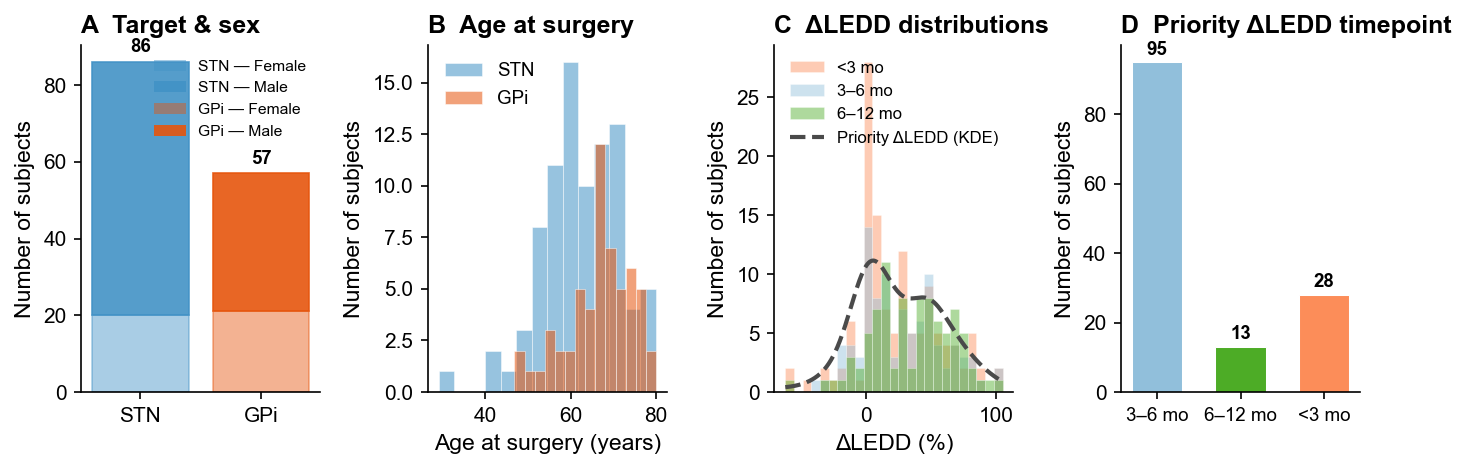

In [11]:
# figure 1: cohort overview  
# panel A: stacked bar — target × sex
# panel B: age distribution by target
# panel C: ΔLEDD distributions by timepoint + priority KDE
# panel D: bar — timepoint contribution to priority ΔLEDD

fig = plt.figure(figsize=(11, 3))
gs  = gridspec.GridSpec(1, 4, figure=fig, wspace=0.45)

ax_bar  = fig.add_subplot(gs[0])
ax_age  = fig.add_subplot(gs[1])
ax_hist = fig.add_subplot(gs[2])
ax_tp   = fig.add_subplot(gs[3])

# A: target × sex stacked bar 
d_demo = df.dropna(subset=['target_label', 'sex']).copy()
counts = (d_demo.groupby(['target_label', 'sex'])
          .size().unstack(fill_value=0))
counts = counts.reindex(['STN', 'GPi'])
# sex: 0=Male, 1=Female
for i, (target, color) in enumerate([('STN', C['stn']), ('GPi', C['gpi'])]):
    n_f = counts.loc[target].get(1, 0)
    n_m = counts.loc[target].get(0, 0)
    ax_bar.bar(i, n_f, color=color, alpha=0.45, edgecolor=color, linewidth=0.8, label=f'{target} F')
    ax_bar.bar(i, n_m, bottom=n_f, color=color, alpha=0.9, edgecolor=color, linewidth=0.8, label=f'{target} M')
    ax_bar.text(i, n_f + n_m + 1.5, str(n_f + n_m),
                ha='center', va='bottom', fontsize=9, fontweight='bold')

ax_bar.set_xticks([0, 1]); ax_bar.set_xticklabels(['STN', 'GPi'])
ax_bar.set_ylabel('Number of subjects')
ax_bar.set_title('A  Target & sex', loc='left', fontweight='bold')
legend_els = [
    Patch(facecolor=C['stn'], alpha=0.45, label='STN — Female'),
    Patch(facecolor=C['stn'], alpha=0.9,  label='STN — Male'),
    Patch(facecolor=C['gpi'], alpha=0.45, label='GPi — Female'),
    Patch(facecolor=C['gpi'], alpha=0.9,  label='GPi — Male'),
]
ax_bar.legend(handles=legend_els, frameon=False, fontsize=7.5, loc='upper right')

# B: age distribution by target 
for target, color in [('STN', C['stn']), ('GPi', C['gpi'])]:
    ages = df.loc[df['target_label'] == target, 'age'].dropna()
    ax_age.hist(ages, bins=14, alpha=0.55, color=color,
                edgecolor='white', linewidth=0.4, label=target)
ax_age.set_xlabel('Age at surgery (years)')
ax_age.set_ylabel('Number of subjects')
ax_age.set_title('B  Age at surgery', loc='left', fontweight='bold')
ax_age.legend(frameon=False)

# C: ΔLEDD distributions by timepoint 
tp_map = {
    'delta_ledd_pct_lt3mo':   ('<3 mo',   C['tp_03']),
    'delta_ledd_pct_3to6mo':  ('3–6 mo',  C['tp_36']),
    'delta_ledd_pct_6to12mo': ('6–12 mo', C['tp_612']),
}
all_vals = pd.concat([df[c].dropna() for c in ['delta_ledd_pct_lt3mo','delta_ledd_pct_3to6mo','delta_ledd_pct_6to12mo']]).values
xlim_c   = (np.nanpercentile(all_vals, 1) - 5, np.nanpercentile(all_vals, 99) + 5)
bins     = np.linspace(*xlim_c, 26)

for col, (label, color) in tp_map.items():
    vals = df[col].dropna().values
    ax_hist.hist(vals, bins=bins, alpha=0.45, color=color,
                 edgecolor='white', linewidth=0.3, label=label)

# KDE for priority ΔLEDD
xp   = df[OUTCOME].dropna().values
grid = np.linspace(*xlim_c, 400)
kde  = stats.gaussian_kde(xp, bw_method='silverman')
bw   = bins[1] - bins[0]
ax_hist.plot(grid, kde(grid) * len(xp) * bw, color='#4A4A4A',
             lw=2, ls='--', label='Priority ΔLEDD (KDE)', zorder=5)

ax_hist.set_xlabel('ΔLEDD (%)')
ax_hist.set_ylabel('Number of subjects')
ax_hist.set_title('C  ΔLEDD distributions', loc='left', fontweight='bold')
ax_hist.legend(frameon=False, fontsize=8)

# D: Timepoint contribution bar
tp_counts = (df['ledd_timepoint']
             .value_counts()
             .reindex(['3–6 mo', '6–12 mo', '<3 mo']))
tp_colors = [C['tp_36'], C['tp_612'], C['tp_03']]

bars = ax_tp.bar(range(3), tp_counts.values, color=tp_colors,
                 edgecolor='white', linewidth=0.5, width=0.6)
for bar, v in zip(bars, tp_counts.values):
    ax_tp.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 1,
               str(int(v)), ha='center', va='bottom', fontsize=9, fontweight='bold')

ax_tp.set_xticks(range(3))
ax_tp.set_xticklabels(tp_counts.index, fontsize=9)
ax_tp.set_ylabel('Number of subjects')
ax_tp.set_title('D  Priority ΔLEDD timepoint', loc='left', fontweight='bold')

savefig('Figure1_cohort_overview')
plt.show()

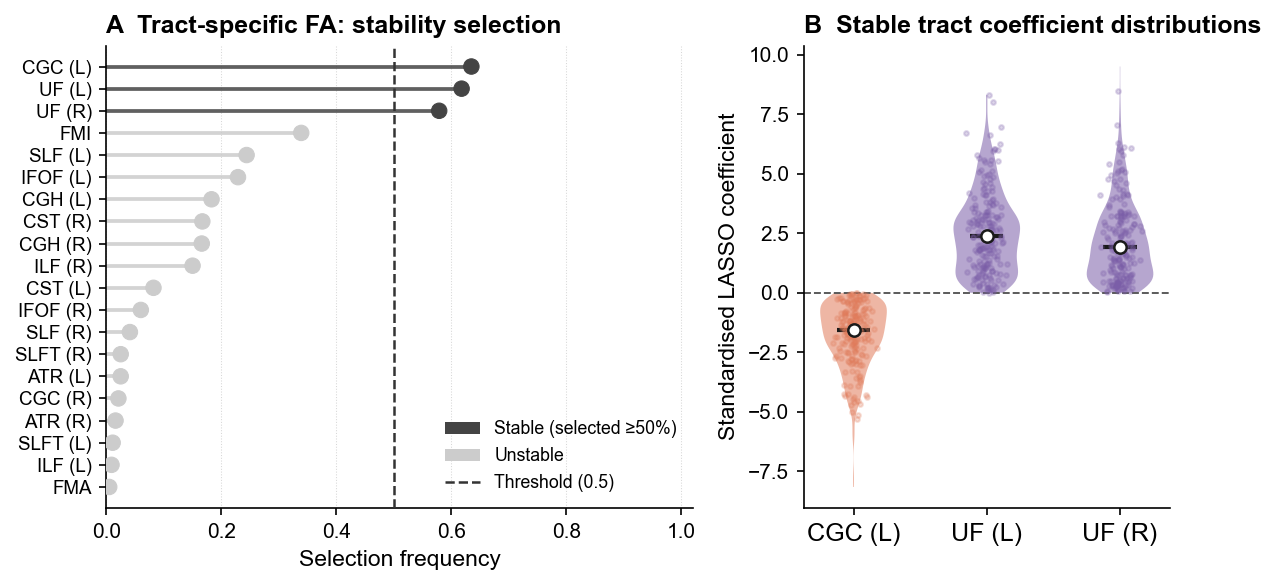

In [12]:
# figure 2: stability selection results

POS_COLOR = '#7B5EA8'   # purple  — positive coefficients
NEG_COLOR = '#E07B5A'   # coral   — negative coefficients

sel_sorted = sel_series.sort_values(ascending=True)
labels_sorted = [TRACT_LABEL_MAP[c] for c in sel_sorted.index]

# dark gray for stable, light gray for unstable
colors_sorted = ['#444444' if f >= STABILITY_THR else '#CCCCCC'
                 for f in sel_sorted.values]

fig, (ax_lol, ax_vio) = plt.subplots(1, 2, figsize=(8, 4),
                                      gridspec_kw={'width_ratios': [1.6, 1]})

# A: lollipop 
y_pos = np.arange(len(sel_sorted))
ax_lol.hlines(y_pos, 0, sel_sorted.values, colors=colors_sorted,
               linewidth=1.8, alpha=0.85)
ax_lol.scatter(sel_sorted.values, y_pos, s=55, c=colors_sorted,
               edgecolors=colors_sorted, zorder=4, linewidth=0.5)
ax_lol.axvline(STABILITY_THR, color='#333333', linewidth=1.2,
               linestyle='--', zorder=5)

ax_lol.set_yticks(y_pos)
ax_lol.set_yticklabels(labels_sorted, fontsize=9)
ax_lol.set_xlabel('Selection frequency')
ax_lol.set_xlim(0, 1.02)
ax_lol.set_title('A  Tract-specific FA: stability selection', loc='left', fontweight='bold')
ax_lol.grid(axis='x', linestyle=':', linewidth=0.5, alpha=0.5)

legend_els = [
    Patch(facecolor='#444444', label='Stable (selected ≥50%)'),
    Patch(facecolor='#CCCCCC', label='Unstable'),
    Line2D([0], [0], color='#333333', linewidth=1.2,
           linestyle='--', label=f'Threshold ({STABILITY_THR})'),
]
ax_lol.legend(handles=legend_els, frameon=False, fontsize=8.5, loc='lower right')

# B: coefficient distributions for stable tracts
rng_jit = np.random.default_rng(42)
n_stable = len(STABLE_TRACTS)

if n_stable > 0:
    positions  = np.arange(n_stable)
    data_vio   = [coef_df[c].replace(0, np.nan).dropna().values for c in STABLE_TRACTS]
    labels_vio = [TRACT_LABEL_MAP[c] for c in STABLE_TRACTS]

    # assign color per tract based on median coefficient sign
    tract_colors = [NEG_COLOR if np.median(d) < 0 else POS_COLOR for d in data_vio]

    vparts = ax_vio.violinplot(data_vio, positions=positions,
                                showmedians=True, showextrema=False)
    for pc, tc in zip(vparts['bodies'], tract_colors):
        pc.set_facecolor(tc)
        pc.set_alpha(0.55)
    vparts['cmedians'].set_color('#1a1a1a')
    vparts['cmedians'].set_linewidth(2)

    for xi, vals, tc in zip(positions, data_vio, tract_colors):
        pts = rng_jit.choice(vals, size=min(200, len(vals)), replace=False)
        ax_vio.scatter(np.full_like(pts, xi) + rng_jit.normal(0, 0.06, len(pts)),
                       pts, s=5, alpha=0.25, color=tc, zorder=3)
        med = np.median(vals)
        ax_vio.scatter(xi, med, s=35, color='white', edgecolors='#1a1a1a',
                       linewidth=1.2, zorder=6)

    ax_vio.axhline(0, color='#555555', linewidth=0.9, linestyle='--')
    ax_vio.set_xticks(positions)
    ax_vio.set_xticklabels(labels_vio, fontsize=12)
    ax_vio.set_ylabel('Standardised LASSO coefficient')
    ax_vio.set_title('B  Stable tract coefficient distributions', loc='left', fontweight='bold',fontsize=12)

    
else:
    ax_vio.text(0.5, 0.5, 'No stable tracts at threshold',
                ha='center', va='center', transform=ax_vio.transAxes)

fig.tight_layout()
savefig('Figure2_stability_selection')
plt.show()

/var/folders/9k/h7xqs2mj5vx3d4cjkkhlwf4r0000gn/T/ipykernel_74442/34172383.py:97: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout()


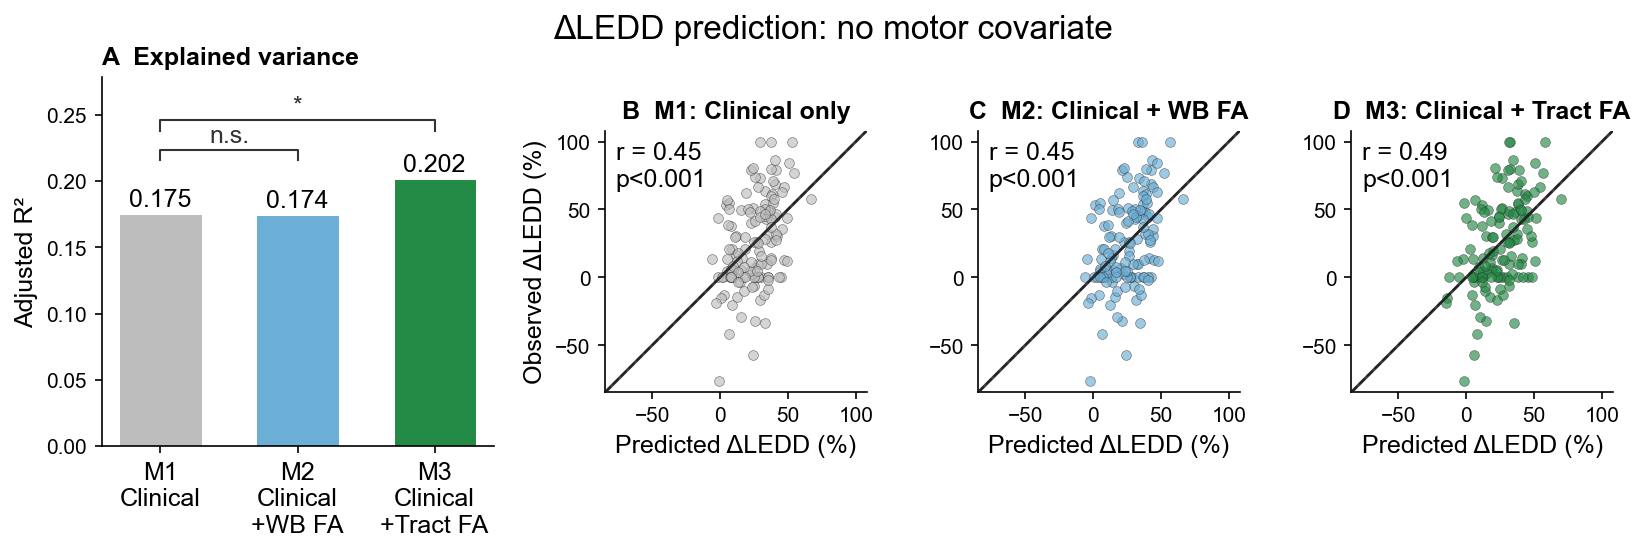

In [13]:
# figure 3: model performance — no motor covariate

def obs_vs_pred_panel(ax, res, title, color, lims):
    y_true = res['yhat'] + res['resid']
    y_pred = res['yhat']

    ax.scatter(y_pred, y_true, s=22, alpha=0.65, color=color,
               edgecolors='#333333', linewidths=0.3, zorder=3)
    ax.plot(lims, lims, '--', color='#555555', lw=1, zorder=2)
 
    m, b = np.polyfit(y_pred, y_true, 1)
    xx = np.linspace(*lims, 200)
    ax.plot(xx, m * xx + b, color='#1a1a1a', lw=1.4, alpha=0.85, zorder=4)

    r, p = stats.pearsonr(y_true, y_pred)
    p_str = f'p={p:.3f}' if p >= 0.001 else 'p<0.001'
    ax.text(0.04, 0.96,
            f'r = {r:.2f}\n{p_str}',
            transform=ax.transAxes, ha='left', va='top', fontsize=12,
            bbox=dict(boxstyle='round,pad=0.3', fc='white', ec='none', alpha=0.85))

    ax.set_xlim(*lims); ax.set_ylim(*lims)
    ax.set_title(title, fontsize=12, fontweight='bold')
    ax.set_aspect('equal')


res_none = results_all['None']
r2_vals  = [res_none[m]['r2_adj'] for m in ('M1', 'M2', 'M3')]

# shared axis limits
all_y = np.concatenate([res_none[m]['yhat'] + res_none[m]['resid'] for m in ('M1','M2','M3')])
all_p = np.concatenate([res_none[m]['yhat'] for m in ('M1','M2','M3')])
pad   = 8
lims  = (min(all_y.min(), all_p.min()) - pad, max(all_y.max(), all_p.max()) + pad)

fig = plt.figure(figsize=(13, 3.2))
gs  = gridspec.GridSpec(1, 4, figure=fig, width_ratios=[1.5, 1, 1, 1], wspace=0.38)
ax_r2 = fig.add_subplot(gs[0])
ax_m1 = fig.add_subplot(gs[1])
ax_m2 = fig.add_subplot(gs[2])
ax_m3 = fig.add_subplot(gs[3])

# A: adj. R² bar chart with significance brackets 
model_labels = ['M1\nClinical', 'M2\nClinical\n+WB FA', 'M3\nClinical\n+Tract FA']
bar_cols     = [C['M1'], C['M2'], C['M3']]
x_bars       = np.array([0, 1, 2])

bars = ax_r2.bar(x_bars, r2_vals, color=bar_cols,
                 edgecolor='white', linewidth=0.5, width=0.6)

# label each bar with its R² value
for bar, rv in zip(bars, r2_vals):
    ax_r2.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.002,
               f'{rv:.3f}', ha='center', va='bottom', fontsize=12)

# significance brackets — bracket_top sets how high above the tallest bar
bar_top   = max(r2_vals)
y_bracket = bar_top + 0.022   # baseline bracket height
bracket_h = 0.008              # tick drop

def draw_bracket(ax, x1, x2, y, tick_h, label, fontsize=8.5):
    # horizontal bar
    ax.plot([x1, x1, x2, x2], [y - tick_h, y, y, y - tick_h],
            color='#333333', lw=1.0, clip_on=False)
    ax.text((x1 + x2) / 2, y + 0.002, label,
            ha='center', va='bottom', fontsize=12, color='#333333')

# M1 vs M2 bracket 
F12, _, _, p12 = nested_f_test(res_none['M1'], res_none['M2'])
draw_bracket(ax_r2, 0, 1, y_bracket, bracket_h,
             'n.s.' if p12 >= 0.05 else '*')

# M1 vs M3 bracket
F13, _, _, p13 = nested_f_test(res_none['M1'], res_none['M3'])
sig_label = ('***' if p13 < 0.001 else '**' if p13 < 0.01
             else '*' if p13 < 0.05 else 'n.s.')
draw_bracket(ax_r2, 0, 2, y_bracket + 0.022, bracket_h, sig_label)

ax_r2.set_xticks(x_bars)
ax_r2.set_xticklabels(model_labels, fontsize=12)
ax_r2.set_ylabel('Adjusted R²', fontsize=12)
ax_r2.set_title('A  Explained variance', loc='left', fontsize=12, fontweight='bold')
ax_r2.set_ylim(0, y_bracket + 0.055)   # headroom for both brackets

# B–D: obs vs pred scatter 
for ax, m_key, col, lbl in [
    (ax_m1, 'M1', C['M1'], 'B  M1: Clinical only'),
    (ax_m2, 'M2', C['M2'], 'C  M2: Clinical + WB FA'),
    (ax_m3, 'M3', C['M3'], 'D  M3: Clinical + Tract FA'),
]:
    obs_vs_pred_panel(ax, res_none[m_key], lbl, col, lims)
    if ax is ax_m1:
        ax.set_ylabel('Observed ΔLEDD (%)', fontsize=12)
    ax.set_xlabel('Predicted ΔLEDD (%)', fontsize=12)

fig.suptitle('ΔLEDD prediction: no motor covariate', fontsize=16, y=1.01)
fig.tight_layout()
savefig('Figure3_model_performance_no_motor')
plt.show()

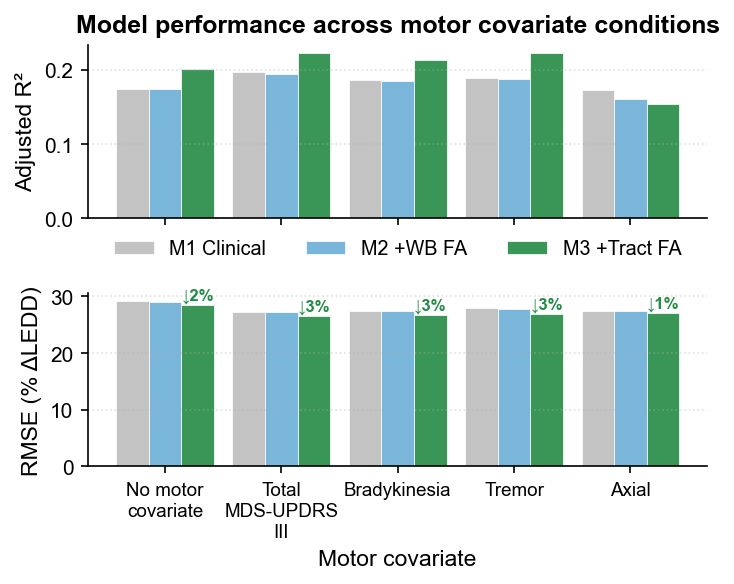

In [14]:
# figure 4: motor-adjusted model summary 
# grouped bar chart: Adj. R² for M1 vs M3 across motor covariate conditions
# with RMSE reduction annotations

motor_conditions = ['None'] + list(MOTOR_VARS.keys())
x_pos  = np.arange(len(motor_conditions))
width  = 0.28
model_keys   = ['M1', 'M2', 'M3']
model_labels = ['M1 Clinical', 'M2 +WB FA', 'M3 +Tract FA']
model_cols   = [C['M1'], C['M2'], C['M3']]

fig, (ax_r2, ax_rmse) = plt.subplots(2, 1, figsize=(5, 4), sharex=True)

for i, (mk, ml, mc) in enumerate(zip(model_keys, model_labels, model_cols)):
    r2s   = [results_all[cond][mk]['r2_adj']  for cond in motor_conditions]
    rmses = [results_all[cond][mk]['rmse']     for cond in motor_conditions]
    ax_r2.bar(x_pos + (i - 1) * width, r2s,   width=width, color=mc,
              edgecolor='white', linewidth=0.4, label=ml, alpha=0.9)
    ax_rmse.bar(x_pos + (i - 1) * width, rmses, width=width, color=mc,
                edgecolor='white', linewidth=0.4, alpha=0.9)

# annotate RMSE 
for xi, cond in zip(x_pos, motor_conditions):
    r1 = results_all[cond]['M1']['rmse']
    r3 = results_all[cond]['M3']['rmse']
    pct = (r1 - r3) / r1 * 100
    ax_rmse.text(xi + width, r3 + 0.3, f'↓{pct:.0f}%',
                 ha='center', va='bottom', fontsize=8, color=C['M3'], fontweight='bold')

ax_r2.set_ylabel('Adjusted R²')
ax_r2.set_title('Model performance across motor covariate conditions', fontweight='bold')
ax_r2.legend(frameon=False, ncol=3, loc='upper center', bbox_to_anchor=(0.5, -0.02),fontsize=9.5)
ax_r2.grid(axis='y', linestyle=':', alpha=0.4)

ax_rmse.set_ylabel('RMSE (% ΔLEDD)')
ax_rmse.set_xticks(x_pos)
ax_rmse.set_xticklabels(
    ['No motor\ncovariate'] + [c.replace(' ', '\n') for c in list(MOTOR_VARS.keys())],
    fontsize=9)
ax_rmse.grid(axis='y', linestyle=':', alpha=0.4)
ax_rmse.set_xlabel('Motor covariate')

fig.tight_layout()
savefig('Figure4_motor_adjusted_summary')
plt.show()

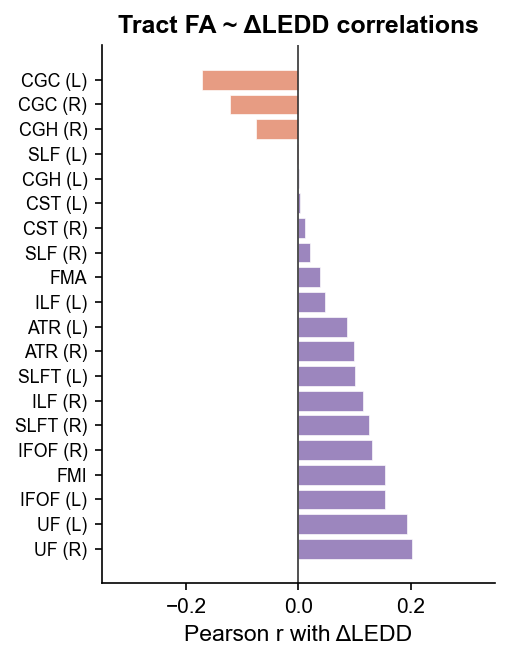

Tract-ΔLEDD correlations:


,Tract,r,p
0,UF (R),0.202289,0.019539
1,UF (L),0.193085,0.025400
2,IFOF (L),0.154589,0.072339
3,FMI,0.154055,0.080118
4,IFOF (R),0.130411,0.130209
5,SLFT (R),0.125539,0.145316
6,ILF (R),0.114109,0.185913
7,SLFT (L),0.101103,0.241529
8,ATR (R),0.098744,0.252745
9,ATR (L),0.085972,0.319643


In [15]:
# supplementary: tract FA correlations with ΔLEDD
# correlation matrix-style heatmap: each tract vs ΔLEDD (Pearson r, uncorrected)

d_cor = df[[OUTCOME] + TRACT_FA_COLS].dropna(subset=[OUTCOME])

r_vals, p_vals = [], []
for col in TRACT_FA_COLS:
    sub = d_cor[[OUTCOME, col]].dropna()
    if len(sub) > 10:
        r, p = stats.pearsonr(sub[OUTCOME], sub[col])
    else:
        r, p = np.nan, np.nan
    r_vals.append(r)
    p_vals.append(p)

cor_df = pd.DataFrame({
    'Tract': [TRACT_LABEL_MAP[c] for c in TRACT_FA_COLS],
    'r':     r_vals,
    'p':     p_vals,
}).sort_values('r', ascending=False)

fig, ax = plt.subplots(figsize=(3.5, 4.5))
vals   = cor_df['r'].values
clrs   = ['#7B5EA8' if v > 0 else '#E07B5A' for v in vals]
y_tick = np.arange(len(cor_df))

ax.barh(y_tick, vals, color=clrs, alpha=0.75, edgecolor='white', linewidth=0.4)
ax.axvline(0, color='#333333', linewidth=0.8)

# mark FDR-significant (Benjamini-Hochberg)
# BH FDR correction (works on any scipy version)
def bh_fdr(p_vals, alpha=0.05):
    p = np.asarray(p_vals, dtype=float)
    n = len(p)
    order = np.argsort(p)
    ranks = np.arange(1, n + 1)
    threshold = alpha * ranks / n
    below = p[order] <= threshold
    if below.any():
        cutoff = p[order][below].max()
    else:
        cutoff = 0.0
    return p <= cutoff

p_arr  = np.array(cor_df['p'].fillna(1))
rejected = bh_fdr(p_arr)

for yi, sig in enumerate(rejected):
    if sig:
        ax.text(vals[yi] + (0.005 if vals[yi] >= 0 else -0.005),
                yi, '★', va='center',
                ha='left' if vals[yi] >= 0 else 'right', fontsize=9)

ax.set_yticks(y_tick)
ax.set_yticklabels(cor_df['Tract'], fontsize=8.5)
ax.set_xlabel('Pearson r with ΔLEDD')
ax.set_title('Tract FA ~ ΔLEDD correlations', fontweight='bold')
ax.set_xlim(-0.35, 0.35)

fig.tight_layout()
savefig('FigureS1_tract_LEDD_correlations')
plt.show()

print('Tract-ΔLEDD correlations:')
display(cor_df.reset_index(drop=True))

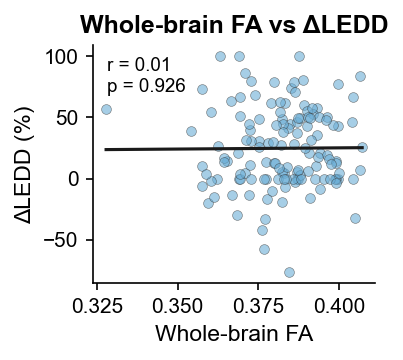

In [16]:
# supplementary: WB FA vs ΔLEDD scatter 

d_wb = df[[OUTCOME, WB_FA_COL]].dropna()
r_wb, p_wb = stats.pearsonr(d_wb[OUTCOME], d_wb[WB_FA_COL])

fig, ax = plt.subplots(figsize=(2.7,2.5))
ax.scatter(d_wb[WB_FA_COL], d_wb[OUTCOME], s=22, alpha=0.6, color=C['M2'],
           edgecolors='#333333', linewidths=0.3)
m, b = np.polyfit(d_wb[WB_FA_COL], d_wb[OUTCOME], 1)
xx = np.linspace(d_wb[WB_FA_COL].min(), d_wb[WB_FA_COL].max(), 200)
ax.plot(xx, m*xx+b, color='#1a1a1a', lw=1.5)
p_str = f'p = {p_wb:.3f}' if p_wb >= 0.001 else 'p < 0.001'
ax.text(0.05, 0.95, f'r = {r_wb:.2f}\n{p_str}', transform=ax.transAxes,
        va='top', fontsize=9,
        bbox=dict(boxstyle='round,pad=0.3', fc='white', ec='none', alpha=0.85))
ax.set_xlabel('Whole-brain FA')
ax.set_ylabel('ΔLEDD (%)')
ax.set_title('Whole-brain FA vs ΔLEDD', fontweight='bold')
fig.tight_layout()
savefig('FigureS2_WBFA_vs_LEDD')
plt.show()

In [17]:
# print final summary 
print('=' * 65)
print('FINAL MODEL SUMMARY (No motor covariate)')
print('=' * 65)
res = results_all['None']
for mk, ml in [('M1','M1 – Clinical only'),
               ('M2','M2 – Clinical + Whole-brain FA'),
               ('M3','M3 – Clinical + Tract-specific FA')]:
    r = res[mk]
    print(f'{ml}')
    print(f'  n={r["n"]}  Adj.R²={r["r2_adj"]:.3f}  AIC={r["aic"]:.1f}  '
          f'RMSE={r["rmse"]:.1f}  MAE={r["mae"]:.1f}')

F12, _, _, p12 = nested_f_test(res['M1'], res['M2'])
F13, _, _, p13 = nested_f_test(res['M1'], res['M3'])
print(f'\nNested F-test M1→M2: F={F12:.2f}, p={p12:.3f}')
print(f'Nested F-test M1→M3: F={F13:.2f}, p={p13:.3f}')
print(f'\nStable tracts: {", ".join([TRACT_LABEL_MAP[c] for c in STABLE_TRACTS])}')
print('\nAll figures saved to ./figures/')

FINAL MODEL SUMMARY (No motor covariate)
M1 – Clinical only
  n=136  Adj.R²=0.175  AIC=1313.3  RMSE=29.2  MAE=23.3
M2 – Clinical + Whole-brain FA
  n=136  Adj.R²=0.174  AIC=1314.4  RMSE=29.1  MAE=23.2
M3 – Clinical + Tract-specific FA
  n=132  Adj.R²=0.202  AIC=1275.3  RMSE=28.5  MAE=22.8

Nested F-test M1→M2: F=0.93, p=0.336
Nested F-test M1→M3: F=3.12, p=0.028

Stable tracts: CGC (L), UF (L), UF (R)

All figures saved to ./figures/
